# Downloading and plotting Copernicus data with Python

First, create a virtual environment: 
`conda create --name bioc26` 

and activate it:
`conda activate bioc26`

Within this virtual environment, we can now install the libraries needed:
`conda install matplotlib xarray netCDF4 numpy pandas cartopy jupyter copernicusmarine`

To deactivate the virtual environment (e.g., end of the day), do `conda deactivate`.

When selecting the kernel in VS code, make sure to select 'bioc26'. 

In the reminal, run `copernicusmarine login` to store your login credentials, which is needed later for the data download.

## Loading libraries and data

In [95]:

# load libraries

from datetime import timedelta as delta
from glob import glob

import matplotlib.pyplot as plt
import xarray as xr

import netCDF4 as nc
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='50m', edgecolor='k', facecolor=cfeature.COLORS['land'])
# ocean = cfeature.NaturalEarthFeature('physical', 'ocean', \
#     scale='50m', edgecolor='w', facecolor=cfeature.COLORS['water'])

In [96]:
# create data directory
import os

os.makedirs('data', exist_ok=True)

## Downloading Copernicus data

Additional to using the Copernicus website, you can also download data programmatically using the copernicusmarine API. 
Via the website, you can also create the python command based on your pre selection of data and paste it below. 
In this example, we download a Level 3 data product of total and plankton functional type (PFT) chlorophyll concentrations. 

In [97]:
# load physical data

import copernicusmarine

# for this to work, install copernicusmarine toolbox first (either with pip or conda) and run `copernicusmarine login` 
# in the terminal to store your login credentials

#dsname = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
#dsname = "cmems_obs-oc_bal_bgc-plankton_nrt_l3-olci-300m_P1D"
sst_name = "DMI-BALTIC-SST-L3S-NRT-OBS_FULL_TIME_SERIE"
bottom_sal_name = "cmems_mod_bal_phy_anfc_P1D-m_salinity_bitesize"
chl_name = "cmems_obs-oc_bal_bgc-plankton_my_l3-multi-1km_P1D_chl_bitesize"
oxy20m_name = "cmems_mod_bal_bgc_anfc_P1D-m_oxygen_20m_bitesize"


In [98]:
# load data (into your workspace)

sst_ds = xr.open_dataset(f"data/{sst_name}.nc")
bottom_sal_ds = xr.open_dataset(f"data/{bottom_sal_name}.nc")
chl_ds = xr.open_dataset(f"data/{chl_name}.nc")
oxy20m_ds = xr.open_dataset(f"data/{oxy20m_name}.nc")

In [99]:
# inspect: CHECK THE DIMENSION!!!!!!!

sst_ds
chl_ds
bottom_sal_ds
oxy20m_ds

<xarray.Dataset> Size: 34MB
Dimensions:    (time: 1334, depth: 1, latitude: 90, longitude: 71)
Coordinates:
  * time       (time) datetime64[ns] 11kB 2022-11-01 2022-11-02 ... 2026-06-26
  * depth      (depth) float32 4B 15.6
  * latitude   (latitude) float32 360B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float32 284B 9.042 9.069 9.097 ... 10.93 10.96 10.99
Data variables:
    o2         (time, depth, latitude, longitude) float32 34MB ...
Attributes:
    Conventions:       CF-1.11
    title:             CMEMS ERGOM daily integrated model fields
    institution:       Baltic MFC, PU Swedish Meteorological and Hydrological...
    source:            CMEMS BAL MFC NEMO model output converted to NetCDF
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        https://marine.copernicus.eu/
    comment:           Data on cropped native product grid. Horizontal veloci...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  BALTICSEA_ANALYSISFORECAST_BGC_003_007
    subset:datasetId:  cmems_mod_bal_bgc_anfc_P1D-m_202411
    subset:date:       2026-06-19T05:54:02.995Z

In [100]:
# look at SST variable: (last time step, all lat and lon)

sst_ds.sea_surface_temperature[0,:,:]

<xarray.DataArray 'sea_surface_temperature' (latitude: 76, longitude: 101)> Size: 31kB
[7676 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 304B 54.0 54.02 54.04 ... 55.46 55.48 55.5
  * longitude  (longitude) float32 404B 9.0 9.02 9.04 9.06 ... 10.96 10.98 11.0
    time       datetime64[ns] 8B 2019-03-11
Attributes:
    units:          kelvin
    standard_name:  sea_surface_temperature
    long_name:      Sea surface foundation temperature
    comment:        Foundation sea surface temperature of the ocean
    source:         OSI-SAF and GHRSST L2P satellite SST products
    valid_max:      318.15
    valid_min:      270.15

Cartopy is a powerful tool for creating beautiful maps in earth system scuiscience using python. 
More information and documentation can be found here: https://cartopy.readthedocs.io/stable/



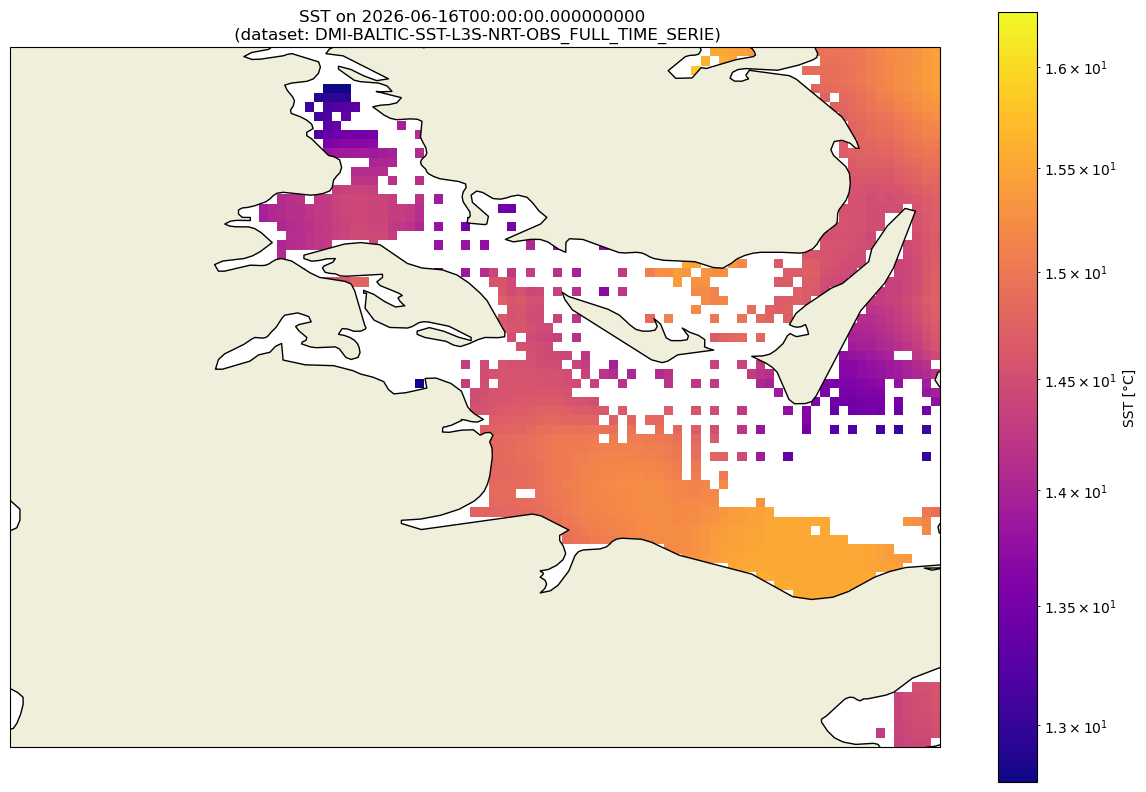

In [101]:
## create our first map of total chlorophyll:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colors

# some plotting helpers
land = cfeature.NaturalEarthFeature('physical', 'land', \
    scale='10m', edgecolor='k', facecolor=cfeature.COLORS['land'])


fig = plt.figure(figsize=(15, 10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(land)

# set time index
time_dx = -3 # select last time step here


# see this page for more info on the arguments of pcolormesh: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html
# and colormaps: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.pcolormesh(sst_ds.longitude, 
               sst_ds.latitude, 
               sst_ds.sea_surface_temperature[time_dx,:,:]-273.15, # select last time step here
               transform=ccrs.PlateCarree(), 
               cmap='plasma',
               norm=colors.LogNorm()) # log-normalise color scale

plt.title(f"SST on {sst_ds.time[time_dx].values} \n (dataset: {dsname})")

plt.colorbar(label='SST [°C]')
plt.show()

In [102]:
# # plot environmental variables together in a 2x2 grid of subplots: 
# idx = -3; # set here for time to plot

# fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

# fig.suptitle(f"Environmental variables on {sst_ds.time[0].values}")

# # log-normalise color scale; apply to all colormesh calls to ensure same colorbar scale
# norm = colors.LogNorm(vmin = 0.1, vmax = 3) 

# # SST
# m = axs[0,0].pcolormesh(
#                sst_ds.longitude, 
#                sst_ds.latitude, 
#                sst_ds.sea_surface_temperature[idx,:,:], # select first time step here
#                transform=ccrs.PlateCarree(), 
#                cmap='plasma',
#                norm=norm) # log-normalise color scale
# axs[0,0].add_feature(land, linewidth=0.2)
# axs[0,0].set_title("Sea Surface Temperature")

# # CHLOROPHYLL
# axs[0,1].add_feature(land, linewidth=0.2)
# axs[0,1].pcolormesh(
#                chl_ds.longitude, 
#                chl_ds.latitude, 
#                chl_ds.[idx,:,:], # select first time step here
#                transform=ccrs.PlateCarree(), 
#                cmap='viridis',
#                norm=norm) # log-normalise color scale
# axs[0,1].set_title("NANOPHYTOPLANKTON")

# # Oxygen at 20m depth
# axs[1,0].add_feature(land, linewidth=0.2)
# axs[1,0].pcolormesh(
#                oxy20m_ds.longitude, 
#                oxy20m_ds.latitude, 
#                oxy20m_ds.oxygen[idx,:,:], # select first time step here
#                transform=ccrs.PlateCarree(), 
#                cmap='viridis',
#                norm=norm) # log-normalise color scale
# axs[1,0].set_title("OXYGEN AT 20M DEPTH")

# # SALINITY at bottom
# axs[1,1].add_feature(land, linewidth=0.2)
# axs[1,1].pcolormesh(
#                bottom_sal_ds.longitude, 
#                bottom_sal_ds.latitude, 
#                bottom_sal_ds.salinity[idx,:,:], # select first time step here
#                transform=ccrs.PlateCarree(), 
#                cmap='viridis',
#                norm=norm) # log-normalise color scale
# axs[1,1].set_title("SALINITY AT BOTTOM")

# fig.colorbar( # add a colorbar
#     m,
#     ax=axs,
#     orientation='horizontal',
#     fraction=0.05,
#     pad=0.05,
#     label='Colorbar label'
# )

# plt.show()



In [103]:
## extracting data for a specific location and time series plot:

#54.435	10.193 e.g. Strande
#54.498	10.144 e.g. Stollar Rinne
#54.530	10.040 e.g. Boknis Eck
#54.673	10.129 e.g. Schleimünde
#54.741	10.060 e.g. Geltinger Birk
#54.813	9.914 e.g. Felnsburg6
#54.894	9.793 e.g. Felnsburg7
#54.886	9.606 e.g. Felnsburg8
#54.840	9.501 e.g. Felnsburg9

lh_lat = 54.530
lh_lon = 10.040

# e.g. Kiel Leuchtturm: 54.499199, 10.274029
# lh_lat = 54.499199
# lh_lon = 10.274029

point = sst_ds.sel(latitude=lh_lat, longitude=lh_lon, method='nearest')
point
sst_ds.variables

Frozen({'sea_surface_temperature': <xarray.Variable (time: 2657, latitude: 76, longitude: 101)> Size: 82MB
[20395132 values with dtype=float32]
Attributes:
    units:          kelvin
    standard_name:  sea_surface_temperature
    long_name:      Sea surface foundation temperature
    comment:        Foundation sea surface temperature of the ocean
    source:         OSI-SAF and GHRSST L2P satellite SST products
    valid_max:      318.15
    valid_min:      270.15, 'time': <xarray.IndexVariable 'time' (time: 2657)> Size: 21kB
array(['2019-03-11T00:00:00.000000000', '2019-03-12T00:00:00.000000000',
       '2019-03-13T00:00:00.000000000', ..., '2026-06-16T00:00:00.000000000',
       '2026-06-17T00:00:00.000000000', '2026-06-18T00:00:00.000000000'],
      shape=(2657,), dtype='datetime64[ns]')
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T, 'latitude': <xarray.IndexVariable 'latitude' (latitude: 76)> Size: 304B
array([54.  , 54.02, 54.04, 54.06, 54.08

/opt/anaconda3/envs/bioc26/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/bioc26/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


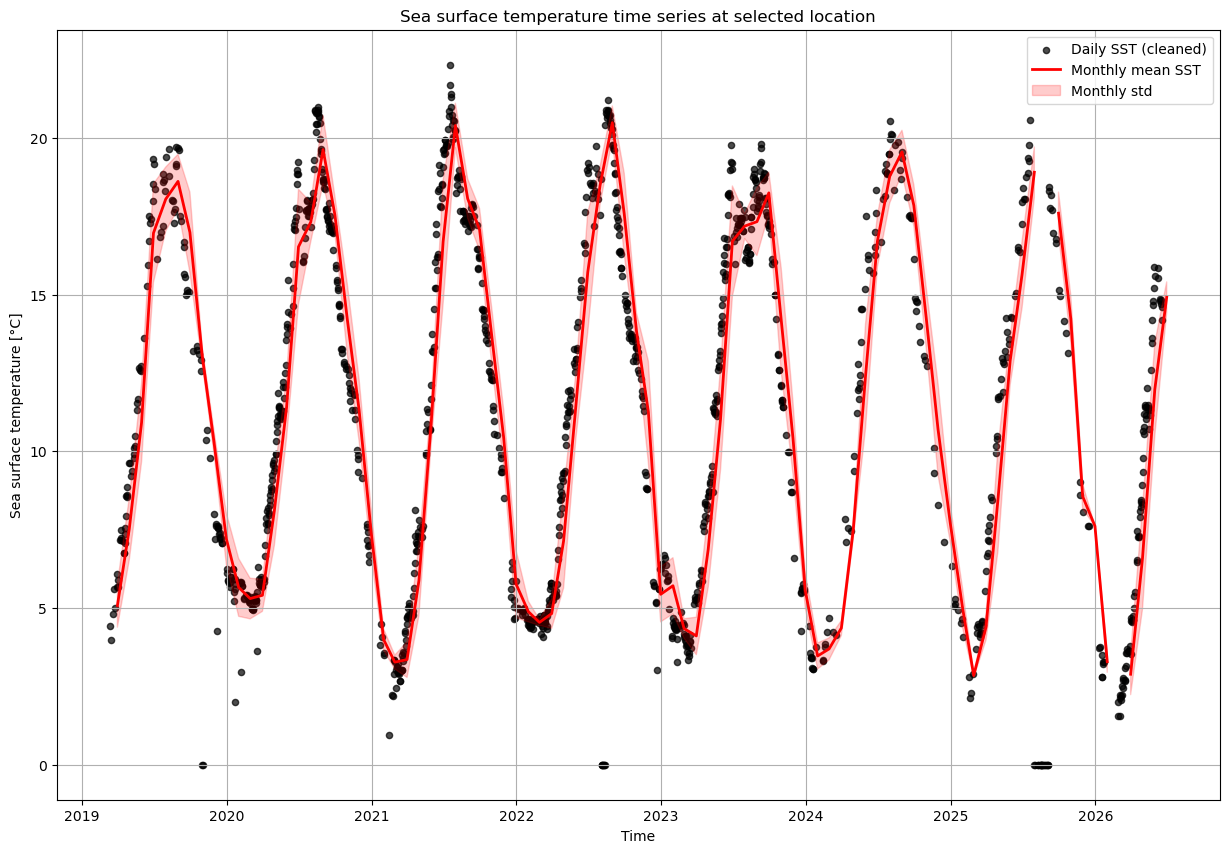

In [104]:
# easy scatter plot of SST at this location over time, with weekly mean overlay and outlier removal:

point_sst = point.sea_surface_temperature-273.15
point_sst = point_sst.dropna(dim='time')

# outlier removal using interquartile range (IQR) per calendar month
monthly_q1 = point_sst.groupby('time.month').quantile(0.25, dim='time')
monthly_q3 = point_sst.groupby('time.month').quantile(0.75, dim='time')
monthly_iqr = monthly_q3 - monthly_q1
monthly_lower = monthly_q1 - 1.5 * monthly_iqr
monthly_upper = monthly_q3 + 1.5 * monthly_iqr

month_index = point_sst['time.month']
monthly_lower_sel = monthly_lower.sel(month=month_index)
monthly_upper_sel = monthly_upper.sel(month=month_index)

# filter out outliers within each month
sst_clean = point_sst.where((point_sst >= monthly_lower_sel) & (point_sst <= monthly_upper_sel))

# resample to monthly means and standard deviation for plotting
monthly_sst = sst_clean.resample(time='1ME').mean()
monthly_sst_std = sst_clean.resample(time='1ME').std()

# plot time series with monthly mean and std overlay
fig = plt.figure(figsize=(15, 10))
plt.scatter(point_sst.time, point_sst, color='black', alpha=0.7, # plot daily data as points
            s=20, label='Daily SST (cleaned)')
plt.plot(monthly_sst.time, monthly_sst, color='red', linewidth=2, label='Monthly mean SST') # plot monthly mean as a line
plt.fill_between(monthly_sst.time, # shading the area between mean - std and mean + std to show variability
                 monthly_sst - monthly_sst_std,
                 monthly_sst + monthly_sst_std,
                 color='red', alpha=0.2, label='Monthly std')

# Axis titles and labels
plt.title('Sea surface temperature time series at selected location')
plt.xlabel('Time')
plt.ylabel('Sea surface temperature [°C]')
plt.legend()
plt.grid(True)
plt.show()
